In [9]:
import librosa 
from pathlib import Path
import numpy as np 
import soundfile as sf
from scipy.io import wavfile
from IPython.display import Audio


In [10]:
path = '/mindhive/mcdermott/www/mturk_stimuli/imgriff/single_word_rec/pilot'

# use resampled words for this: 
wav_paths = list(Path(path, 'giga_200_words').glob('*.wav'))

In [11]:
np.random.seed(1234)

In [12]:

next_pow_2 = lambda x: int(pow(2, np.ceil(np.log2(x))))

def combine_with_noise(clean, noise, snr):
    # get ratio in rms 
    rms_ratio = np.power(10.0, snr / 20.0)
    
    # remove DC of each signal
    clean = clean - clean.mean()
    noise = noise - noise.mean()
    # get rms of each signal
    clean_rms = np.sqrt(np.mean(np.power(clean, 2)))
    noise_rms = np.sqrt(np.mean(np.power(noise, 2)))
    # scale factor for setting noise to desired SNR 
    scale_factor = clean_rms / (noise_rms * rms_ratio)
    # Blend signals 
    noise = noise * scale_factor
    mixture = clean + noise[:len(clean)]
    return mixture 

def get_noise(X, n_fft):
    noise_mag = X * np.exp(
        2*np.pi*1j*np.random.random(len(X)))
    noise = np.real(np.fft.irfft(noise_mag, n_fft))    
    return noise 


In [13]:
# Get wavs to use and pad if needed 

concat_wavs = [librosa.load(wav,sr=16000)[0] for wav in wav_paths]

for ix, wav in enumerate(concat_wavs):
    if wav.shape[0] != (1.75 * 16000):
        pad_len = int((1.75 * 16000) - wav.shape[0])
        concat_wavs[ix] = np.pad(wav, (0, pad_len), mode='constant', constant_values=0)

concat_wavs = np.array(concat_wavs)

## Get average magnitude spectrum of speech

In [14]:
nfft = next_pow_2(concat_wavs.shape[-1]) #int(0.025 * 16000 )
X = np.abs(np.fft.rfft(concat_wavs, n=nfft, axis=-1)).mean(0)


In [15]:
%matplotlib inline 
import matplotlib.pyplot as plt 

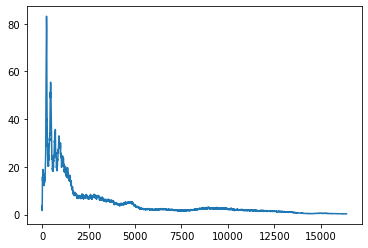

In [16]:
plt.plot(X)

In [27]:
snr_low = -5 # in dB

snr_high = 0 # in dB

low_path = Path(path, 'giga_200_-5_snr')
high_path = Path(path, 'giga_200_0_snr')

if not low_path.is_dir():
    low_path.mkdir()
    
if not high_path.is_dir():
    high_path.mkdir()
    
for wav_path in wav_paths:
    wav_name = wav_path.name
    wav, sr = librosa.load(wav_path, sr=16000)
    # compute noise using computed average spectrum X 
    noise = get_noise(X, nfft)   
    
    mix_low = combine_with_noise(wav, noise, snr_low)
    low_name = Path(low_path, f'snr_{snr_low}_{wav_path.name}')
    sf.write(low_name, mix_low, sr, subtype='PCM_16')
    
    # get new noise for new SNR
    noise = get_noise(X, nfft)   
    mix_high = combine_with_noise(wav, noise, snr_high)
    high_name = Path(high_path, f'snr_{snr_high}_{wav_path.name}')
    sf.write(high_name, mix_high, sr, subtype='PCM_16') 
    
    


## Example mixes

In [28]:
Audio(wav_paths[0], rate=16000)

In [29]:
high_snr = high_path.glob('*.wav')

In [36]:
wav, sr = librosa.load(next(high_snr),sr=16000)
Audio(wav, rate=16000)

In [32]:
low_snr = low_path.glob('*.wav')

In [33]:
wav, sr = librosa.load(next(low_snr),sr=16000)
Audio(wav, rate=16000)